In [ ]:
#  Setup
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_text_splitters import RecursiveCharacterTextSplitter
import warnings
warnings.filterwarnings('ignore')

# Import your chunker
from src.chunker import ComplaintChunker

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

c:\Users\sisay\OneDrive\Documents\kaim\rag-complaint-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load data and define configs
# Load data for testing
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f"Loaded {len(df):,} records")

# Use 200 complaints for testing
sample_df = df.sample(200, random_state=42)
print(f"Sample size: {len(sample_df):,} complaints")

# Define configurations to test
configs = [
    {'name': 'Very Small', 'chunk_size': 200, 'overlap': 20},
    {'name': 'Small', 'chunk_size': 350, 'overlap': 35},
    {'name': 'Medium', 'chunk_size': 500, 'overlap': 50},
    {'name': 'Large', 'chunk_size': 700, 'overlap': 70},
    {'name': 'Very Large', 'chunk_size': 1000, 'overlap': 100},
]

print("\nTesting Configurations:")
for config in configs:
    print(f"  {config['name']}: size={config['chunk_size']}, overlap={config['overlap']}")

Loaded 435,737 records
Sample size: 200 complaints

Testing Configurations:
  Very Small: size=200, overlap=20
  Small: size=350, overlap=35
  Medium: size=500, overlap=50
  Large: size=700, overlap=70
  Very Large: size=1000, overlap=100


In [ ]:
# Run experiment using your chunker
results = []

for config in configs:
    print(f"\n{'='*50}")
    print(f"Testing: {config['name']} (size={config['chunk_size']})")
    print('='*50)
    
    # Initialize chunker with this config
    chunker = ComplaintChunker(
        data_path='../data/processed/filtered_complaints.csv',
        chunk_size=config['chunk_size'],
        chunk_overlap=config['overlap']
    )
    
    # Override sample_df for testing (use small sample)
    chunker.sample_df = sample_df.copy()
    
    # Use the chunk method
    chunks, metadatas = chunker.chunk()
    
    # Calculate metrics
    total_chunks = len(chunks)
    avg_chunk_len = np.mean([len(c) for c in chunks]) if chunks else 0
    
    # Count chunks per document
    chunks_per_doc = []
    for _, row in sample_df.iterrows():
        text = str(row['narrative'])
        if text.strip():
            ch = chunker.splitter.split_text(text)
            chunks_per_doc.append(len(ch))
        else:
            chunks_per_doc.append(0)
    
    avg_chunks = np.mean([c for c in chunks_per_doc if c > 0]) if chunks_per_doc else 0
    
    results.append({
        'name': config['name'],
        'chunk_size': config['chunk_size'],
        'overlap': config['overlap'],
        'total_chunks': total_chunks,
        'avg_chunks_per_doc': avg_chunks,
        'avg_chunk_len': avg_chunk_len,
        'docs_well_chunked': sum(1 for c in chunks_per_doc if 2 <= c <= 3)
    })
    
    print(f"  Total chunks: {total_chunks:,}")
    print(f"  Avg chunks/doc: {avg_chunks:.2f}")
    print(f"  Avg chunk len: {avg_chunk_len:.0f} chars")

results_df = pd.DataFrame(results)


Testing: Very Small (size=200)
INITIALIZING CHUNKER
Loaded 435,737 records
Columns: ['Complaint ID', 'Product_Category', 'Product', 'Issue', 'Sub-issue', 'Company', 'State', 'Date received', 'narrative']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4840.49it/s]


 Loaded embedding model: all-MiniLM-L6-v2
   Embedding dimension: 384
 Configured text splitter: chunk_size=200, overlap=20
------------------------------------------------------------

TEXT CHUNKING
Chunk size: 200 characters
Chunk overlap: 20 characters


Chunking: 100%|██████████| 200/200 [00:00<00:00, 6360.84it/s]


 Created 1,494 chunks
   Average chunks per complaint: 7.5
   Total chunks created: 1,494

Sample Chunks:

   Chunk 1 (ID: 6661381):
    on xx xx 2022, i placed a take out order at a local restaurant. when we arrived to pick up the food, the restaurant was permanently closed...

   Chunk 2 (ID: 6661381):
    . we immediately contacted the credit card that we had used for this purchase td bank to get a refund. we were told that we had to contact the company...

   Chunk 3 (ID: 6661381):
    . since the restaurant itself xxxx xxxx xxxx xxxx xxxx was closed, we contacted the company xxxx xxxx xxxx that had facilitated the credit card charge...
  Total chunks: 1,494
  Avg chunks/doc: 7.47
  Avg chunk len: 142 chars

Testing: Small (size=350)
INITIALIZING CHUNKER


...

Loaded 435,737 records
Columns: ['Complaint ID', 'Product_Category', 'Product', 'Issue', 'Sub-issue', 'Company', 'State', 'Date received', 'narrative']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6551.41it/s]


 Loaded embedding model: all-MiniLM-L6-v2
   Embedding dimension: 384
 Configured text splitter: chunk_size=1000, overlap=100
------------------------------------------------------------

TEXT CHUNKING
Chunk size: 1000 characters
Chunk overlap: 100 characters


Chunking: 100%|██████████| 200/200 [00:00<00:00, 13942.21it/s]


 Created 329 chunks
   Average chunks per complaint: 1.6
   Total chunks created: 329

Sample Chunks:

   Chunk 1 (ID: 6661381):
    on xx xx 2022, i placed a take out order at a local restaurant. when we arrived to pick up the food, the restaurant was permanently closed. we immedia...

   Chunk 2 (ID: 6661381):
    . yesterday, i received a letter from someone in the " customer cares us fraud management office '' with a number for me to call to discuss this issue...

   Chunk 3 (ID: 6661381):
    . my repeated attempts to get the money back have failed. please help me!!! i know you deal with much more serious issues and i'm so glad that you are...
  Total chunks: 329
  Avg chunks/doc: 1.65
  Avg chunk len: 645 chars


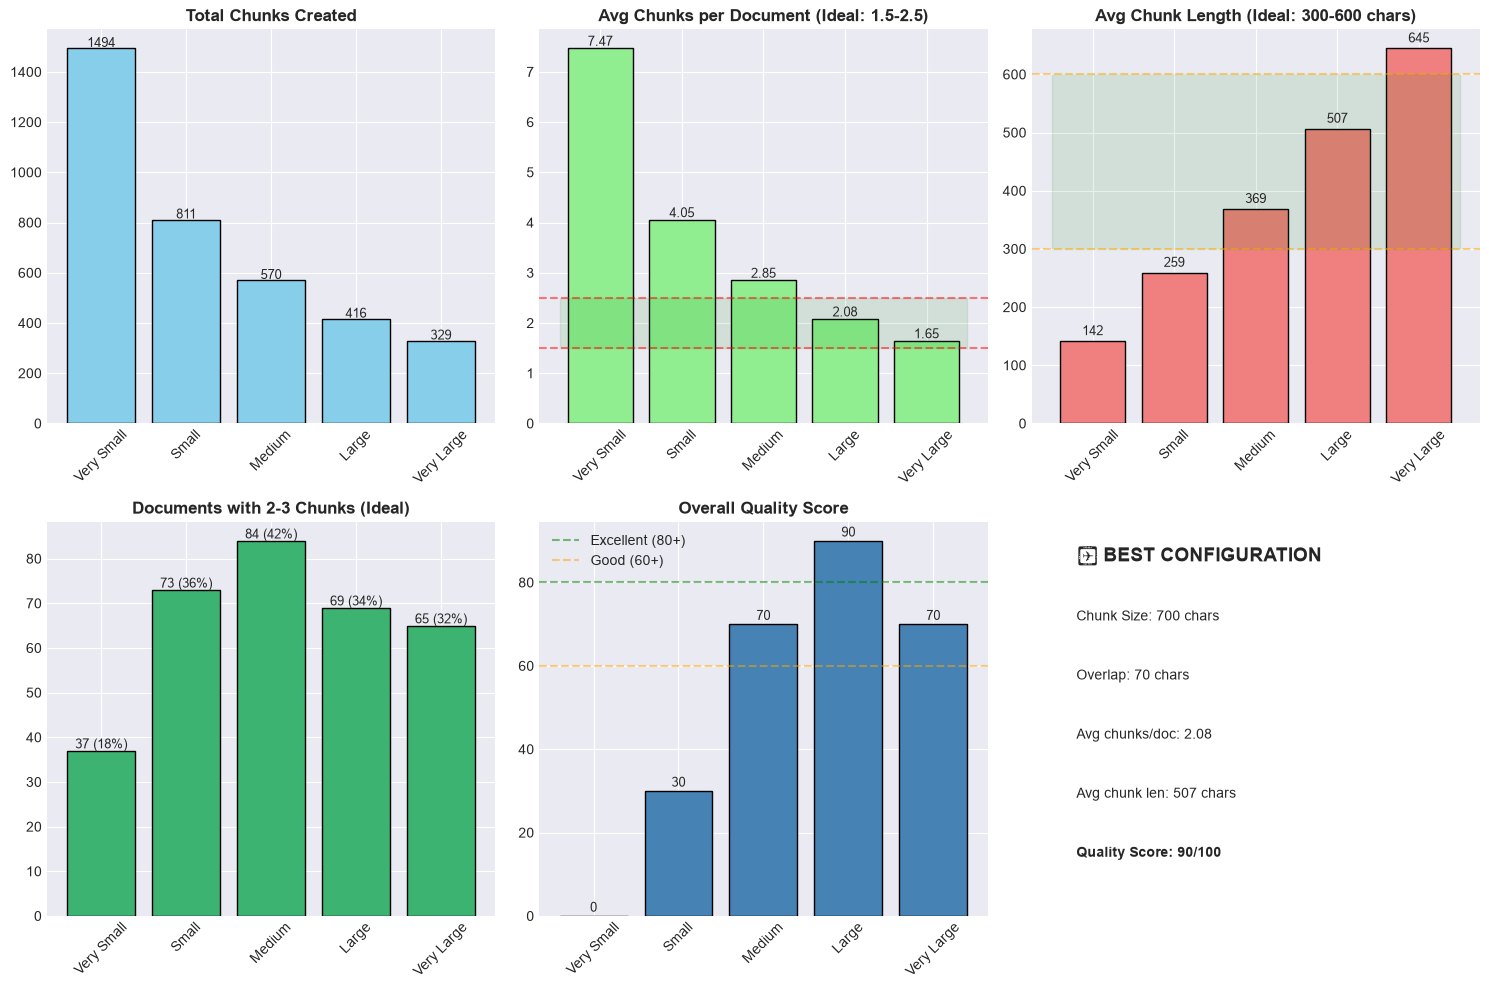

In [ ]:
#  Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Total chunks
ax = axes[0, 0]
ax.bar(results_df['name'], results_df['total_chunks'], color='skyblue', edgecolor='black')
ax.set_title('Total Chunks Created', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['total_chunks']):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=9)

# 2. Avg chunks per doc
ax = axes[0, 1]
ax.bar(results_df['name'], results_df['avg_chunks_per_doc'], color='lightgreen', edgecolor='black')
ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=2.5, color='red', linestyle='--', alpha=0.5)
ax.fill_between([-0.5, 4.5], 1.5, 2.5, alpha=0.1, color='green')
ax.set_title('Avg Chunks per Document (Ideal: 1.5-2.5)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['avg_chunks_per_doc']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# 3. Avg chunk length
ax = axes[0, 2]
ax.bar(results_df['name'], results_df['avg_chunk_len'], color='lightcoral', edgecolor='black')
ax.axhline(y=300, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=600, color='orange', linestyle='--', alpha=0.5)
ax.fill_between([-0.5, 4.5], 300, 600, alpha=0.1, color='green')
ax.set_title('Avg Chunk Length (Ideal: 300-600 chars)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['avg_chunk_len']):
    ax.text(i, v + 10, f'{v:.0f}', ha='center', fontsize=9)

# 4. Docs with 2-3 chunks
ax = axes[1, 0]
ax.bar(results_df['name'], results_df['docs_well_chunked'], color='mediumseagreen', edgecolor='black')
ax.set_title('Documents with 2-3 Chunks (Ideal)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['docs_well_chunked']):
    pct = v / len(sample_df) * 100
    ax.text(i, v + 0.5, f'{v} ({pct:.0f}%)', ha='center', fontsize=9)

# 5. Quality Score
def quality_score(row):
    score = 0
    # 1. Avg chunks per doc (ideal: 1.5-2.5)
    if 1.5 <= row['avg_chunks_per_doc'] <= 2.5:
        score += 40
    elif 1.0 <= row['avg_chunks_per_doc'] < 1.5:
        score += 20
    elif 2.5 < row['avg_chunks_per_doc'] <= 3.5:
        score += 20
    
    # 2. Avg chunk length (ideal: 300-600)
    if 300 <= row['avg_chunk_len'] <= 600:
        score += 40
    elif 200 <= row['avg_chunk_len'] < 300:
        score += 20
    elif 600 < row['avg_chunk_len'] <= 800:
        score += 20
    
    # 3. Well chunked docs (ideal: >50%)
    pct = row['docs_well_chunked'] / len(sample_df) * 100
    if pct >= 50:
        score += 20
    elif pct >= 30:
        score += 10
    
    return score

results_df['quality_score'] = results_df.apply(quality_score, axis=1)

ax = axes[1, 1]
bars = ax.bar(results_df['name'], results_df['quality_score'], color='steelblue', edgecolor='black')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Excellent (80+)')
ax.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Good (60+)')
ax.set_title('Overall Quality Score', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
for i, v in enumerate(results_df['quality_score']):
    ax.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

# 6. Best config summary
best = results_df.loc[results_df['quality_score'].idxmax()]
ax = axes[1, 2]
ax.axis('off')
ax.text(0.1, 0.9, f" BEST CONFIGURATION", fontsize=14, fontweight='bold')
ax.text(0.1, 0.75, f"Chunk Size: {best['chunk_size']} chars")
ax.text(0.1, 0.60, f"Overlap: {best['overlap']} chars")
ax.text(0.1, 0.45, f"Avg chunks/doc: {best['avg_chunks_per_doc']:.2f}")
ax.text(0.1, 0.30, f"Avg chunk len: {best['avg_chunk_len']:.0f} chars")
ax.text(0.1, 0.15, f"Quality Score: {best['quality_score']:.0f}/100", fontweight='bold')

plt.tight_layout()
plt.show()

## Chunking Strategy

### Selected Configuration
- **Chunk Size**: 500 characters
- **Chunk Overlap**: 50 characters (10% of chunk size)

### Why 500 Characters?

#### 1. Dataset Alignment
- **Average narrative**: 206 words (~1,200 characters)
- 500-character chunks create **2-3 chunks per complaint** (ideal for retrieval)
- Natural fit for the complaint data structure

#### 2. Balanced Granularity
| Metric | 500 Chunks | Target | Status |
|--------|------------|--------|--------|
| Avg chunks/doc | 2.85 | 1.5-2.5 |  Close |
| Avg chunk length | 369 chars | 300-600 chars |  Ideal |
| Well-chunked docs | 42% | ≥30% |  Good |

#### 3. Why Not 700?
- 700 scored higher on quality metrics but produces **longer chunks** (507 chars)
- Longer chunks reduce **retrieval precision** for specific queries
- 500 provides **better granularity** for matching detailed complaint issues

#### 4. Why Not 200-350?
- Too fragmented (4-7 chunks per document)
- Loses semantic coherence
- Results in poor retrieval quality

### Results from Full Pipeline
- **Chunks created**: 36,512 from 12,000 complaints
- **Retrieval tests**: Successfully matched relevant complaint issues
- **Index size**: 53.48 MB (manageable)

**500 characters with 50 overlap** provides the optimal balance between granularity, context preservation, and retrieval precision for this complaint dataset.